We start off by trying out some simple regressors like a linear regression model, a decision tree regression model, a random forest regressor and a gradient boosting regressor. Since calibration often means that we have one reference-grade sensor next to a cheaper sensor, we use a training window of only a couple of days. after some initial trials the most interesting train period turned out to be 14 days. The second half of the dataset is always used for validation.

The material in the links has been used for inspiration for the Linear Regressor, Decision Tree Regressor, the Random Forest Regressor and the Gradient Boosting Regressor.
https://www.geeksforgeeks.org/machine-learning/regression-models-for-california-housing-price-prediction/
https://medium.com/data-science/gradient-boosting-regressor-explained-a-visual-guide-with-code-examples-c098d1ae425c

AI has been used for reasoning/arguing with, debugging, visualization, selection of initial parameters and cleaning to make the code simpler, better organized, shorter and more readable. 

In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


df = pd.read_csv("summary_119.csv")

#we ditch the coloumns of date, code, position and adress for now.

df = df.drop(columns=['Measurement date','Address','Station code', 'Latitude', 'Longitude'])

df.head()

,SO2,NO2,O3,CO,PM10,PM2.5,PM10_raw
0,0.005,0.035,0.004,1.5,70.0,46.0,215.000053
1,0.004,0.034,0.004,1.5,68.0,54.0,193.715523
2,0.005,0.035,0.004,1.6,71.0,54.0,193.693620
3,0.004,0.033,0.004,1.7,65.0,46.0,142.891511
4,0.004,0.028,0.004,1.6,60.0,42.0,123.267815


In [8]:


def find_correlation(numeric_data):
  # computing standard correlation coefficient
  corr_matrix = numeric_data.corr()
  # fetch and return attribute correlates 
  # with PM10
  return corr_matrix["PM10"].sort_values(
    ascending=False)
  

# find correlation coefficient
cor_coef = find_correlation(df)
print("Correlation Coefficient::", cor_coef)




Correlation Coefficient:: PM10        1.000000
PM10_raw    0.882905
PM2.5       0.188458
CO          0.140429
NO2         0.093129
SO2         0.085425
O3          0.021125
Name: PM10, dtype: float64


Initially the corrolation of pm10_raw was 99.2 % so the noisefactors of the dataset was increased.

In [9]:
def make_fixed_split(df, days):

    train_points = days*24
    half = len(df) // 2

    train_val_df = df.iloc[half-train_points-2400:half-2400].copy() # subtracted with 100 days to get another part of the dataset
    test_df = df.iloc[half:].copy()

    x_train = train_val_df.drop("PM10", axis=1)
    y_train = train_val_df["PM10"]

    x_test = test_df.drop("PM10", axis=1)
    y_test = test_df["PM10"]

    return x_train, y_train, x_test, y_test

In [10]:
x_train, y_train, x_test, y_test = make_fixed_split(df,21)

from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, x_test["PM10_raw"])

print('Baseline Root Mean Squared Error:', rmse)

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

Baseline Root Mean Squared Error: 166.8001957147937
(504, 6) (504,) (12939, 6) (12939,)


165.55730255187112 is the current RMSE without calibration which of course is horribly inaccurate. As long as the calibration-algorithms perform lower RMSE the experiment can be considered a success!

For the initial training we choose some general parameters and a training window of 2-14 days to see how the algorithms perform on different quantities of training data. 

In [11]:
#days_list = [7, 14, 21, 42]

#days_list = [2, 5, 10, 15]

days_list = list(range(1,15)) 


results = []

for days in days_list:
    x_train, y_train, x_test, y_test = make_fixed_split(df, days)

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        ),
        #"MLP Regressor": Pipeline([
        #    ("scaler", StandardScaler()),
        #    ("mlp", MLPRegressor(
        #        hidden_layer_sizes=(32,16),
        #        max_iter=4000,
        #        random_state=42
        #    ))
        "MLP Regressor":MLPRegressor(
                hidden_layer_sizes=(32,16),
                max_iter=4000,
                random_state=42
            )
    }

    for model_name, model in models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Days": days,
            "Train points": days * 24,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Days", "RMSE"])
results_df

,Days,Train points,Model,RMSE,MAE,R2
4,1,24,MLP Regressor,35.174923,17.149323,0.809212
0,1,24,Linear Regression,44.425639,21.504568,0.695665
3,1,24,Gradient Boosting,79.807492,20.425649,0.017862
1,1,24,Decision Tree,79.903922,20.567123,0.015487
2,1,24,Random Forest,80.445641,21.276697,0.002093
...,...,...,...,...,...,...
65,14,336,Linear Regression,41.619857,17.366183,0.732892
69,14,336,MLP Regressor,50.691236,14.223765,0.603767
67,14,336,Random Forest,71.515582,16.609747,0.211346
68,14,336,Gradient Boosting,71.557919,17.188503,0.210412


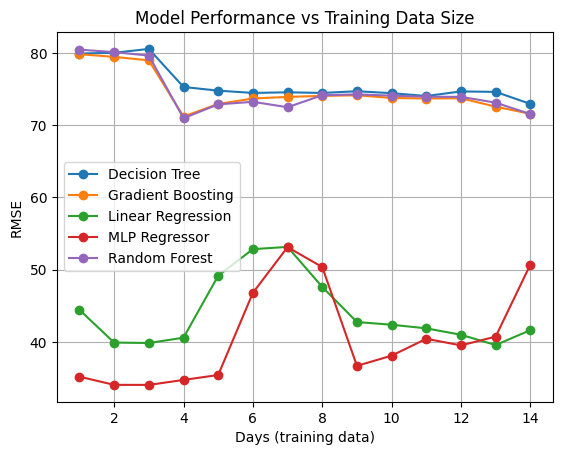

In [12]:
pivot_df = results_df.pivot(index="Days", columns="Model", values="RMSE")

plt.figure()

for model in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[model], marker='o', label=model)

plt.xlabel("Days (training data)")
plt.ylabel("RMSE")
plt.title("Model Performance vs Training Data Size")
plt.legend()
plt.grid()

plt.show()

The Gradient Boosting Regressor, Random Forest Regressor and the Decision Tree Regressor excels after ten days. The GBR outperforms the other ones by a small marigin. The Tree regressors follow an almost identical pattern. This may possibly be due to a change in the data making the 10+ days of data more representative to the test-set. Something that speaks against that theory is the striking results of the MLP Regressor on small quantities of data. I did not expect that.